# PRIMA PROVA DI NEURAL NETWORK

### importazioni

In [10]:
import sys
sys.path.append("../..//ML_app")

from neural_network import neural_network
from cost_functions import sigmoide

In [11]:
import pickle as pkl
import numpy as np

with open('../data/ottani_NIR.pkl', 'rb') as f:
    dizionario = pkl.load(f)
    
# dati train
train_ones = dizionario['train']['NIR']['ones']
train_zeros = dizionario['train']['NIR']['zeros']
train_labels = dizionario['train']['labels']
train_x = np.concatenate((train_zeros, train_ones))

# dati test
test_ones = dizionario['test']['NIR']['ones']
test_zeros = dizionario['test']['NIR']['zeros']
test_labels = dizionario['test']['labels']
test_x = np.concatenate((test_zeros, test_ones))

### SMOOTHING 

In [12]:
from scipy.signal import savgol_filter

window_size = 11
poly_order = 3

for i in range(train_x.shape[0]):
    train_x[i] = savgol_filter(train_x[i], window_size, poly_order)

for j in range(test_x.shape[0]):
    test_x[j] = savgol_filter(test_x[j], window_size, poly_order)

---

## neural network con PCA

In [13]:
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

In [14]:
pipe = Pipeline([
    # Step 1: Scaling
    ("scaling", MinMaxScaler()),       
    
    # Step 2: Riduzione dimensionalità (PCA)
    ("reduce_dim", PCA(n_components=7, random_state=None)),
    
    # Step 3: Classificatore
    ("classify", neural_network(
        random_state=None,
        epoche=100_000,
        nn_learning_rate = 0.8,
        activation_function = 'sigmoide',
        return_errors = True
        )
    ) 
])

lista_ultimi_errori = pipe.fit(train_x, train_labels)

### training

TypeError: float() argument must be a string or a real number, not 'MinMaxScaler'

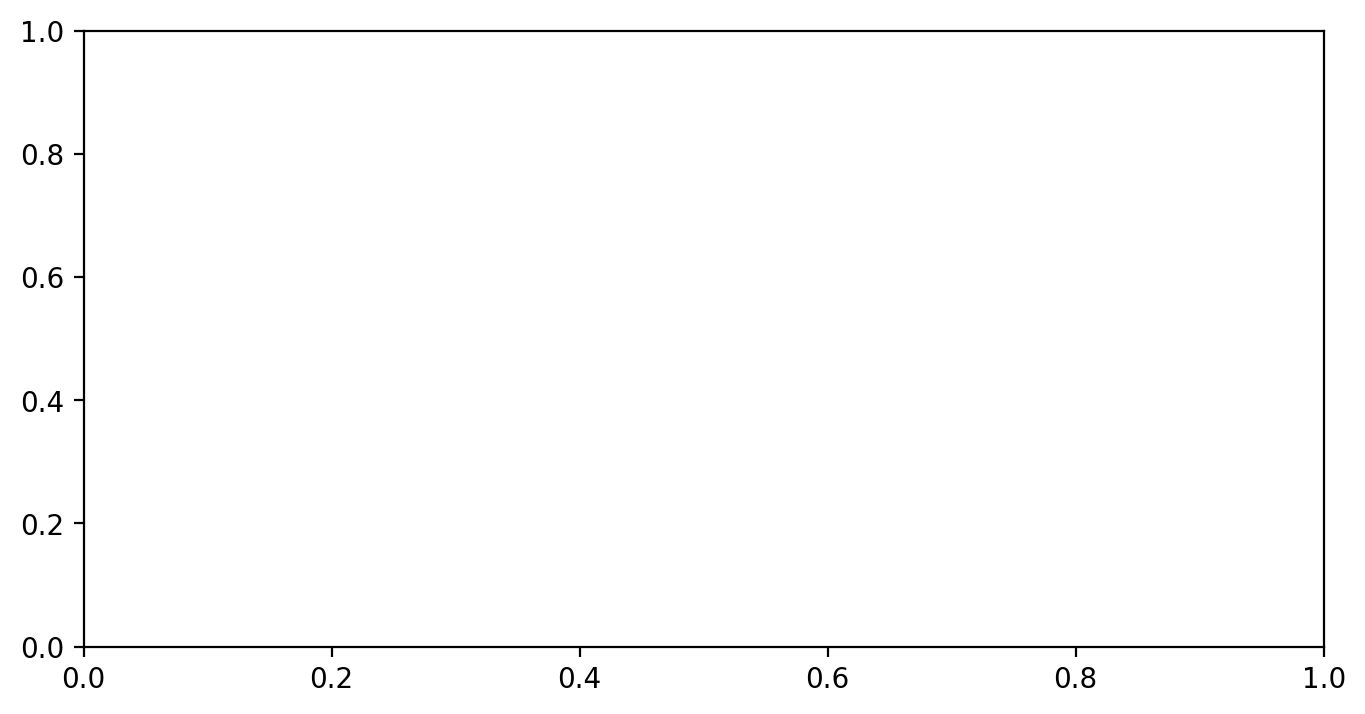

In [15]:
import matplotlib.pyplot as plt

#fig, ax = plt.subplots(1, 2, figsize=(20, 8), dpi=150)

x = range(np.array(lista_ultimi_errori).shape[0])[:1000]
y = np.array(lista_ultimi_errori)[:1000]

plt.figure(figsize=(8,4), dpi=200)
plt.scatter(x,y)
plt.xlabel("Epoca")
plt.ylabel("MSE al termine epoca")

Text(0, 0.5, 'MSE')

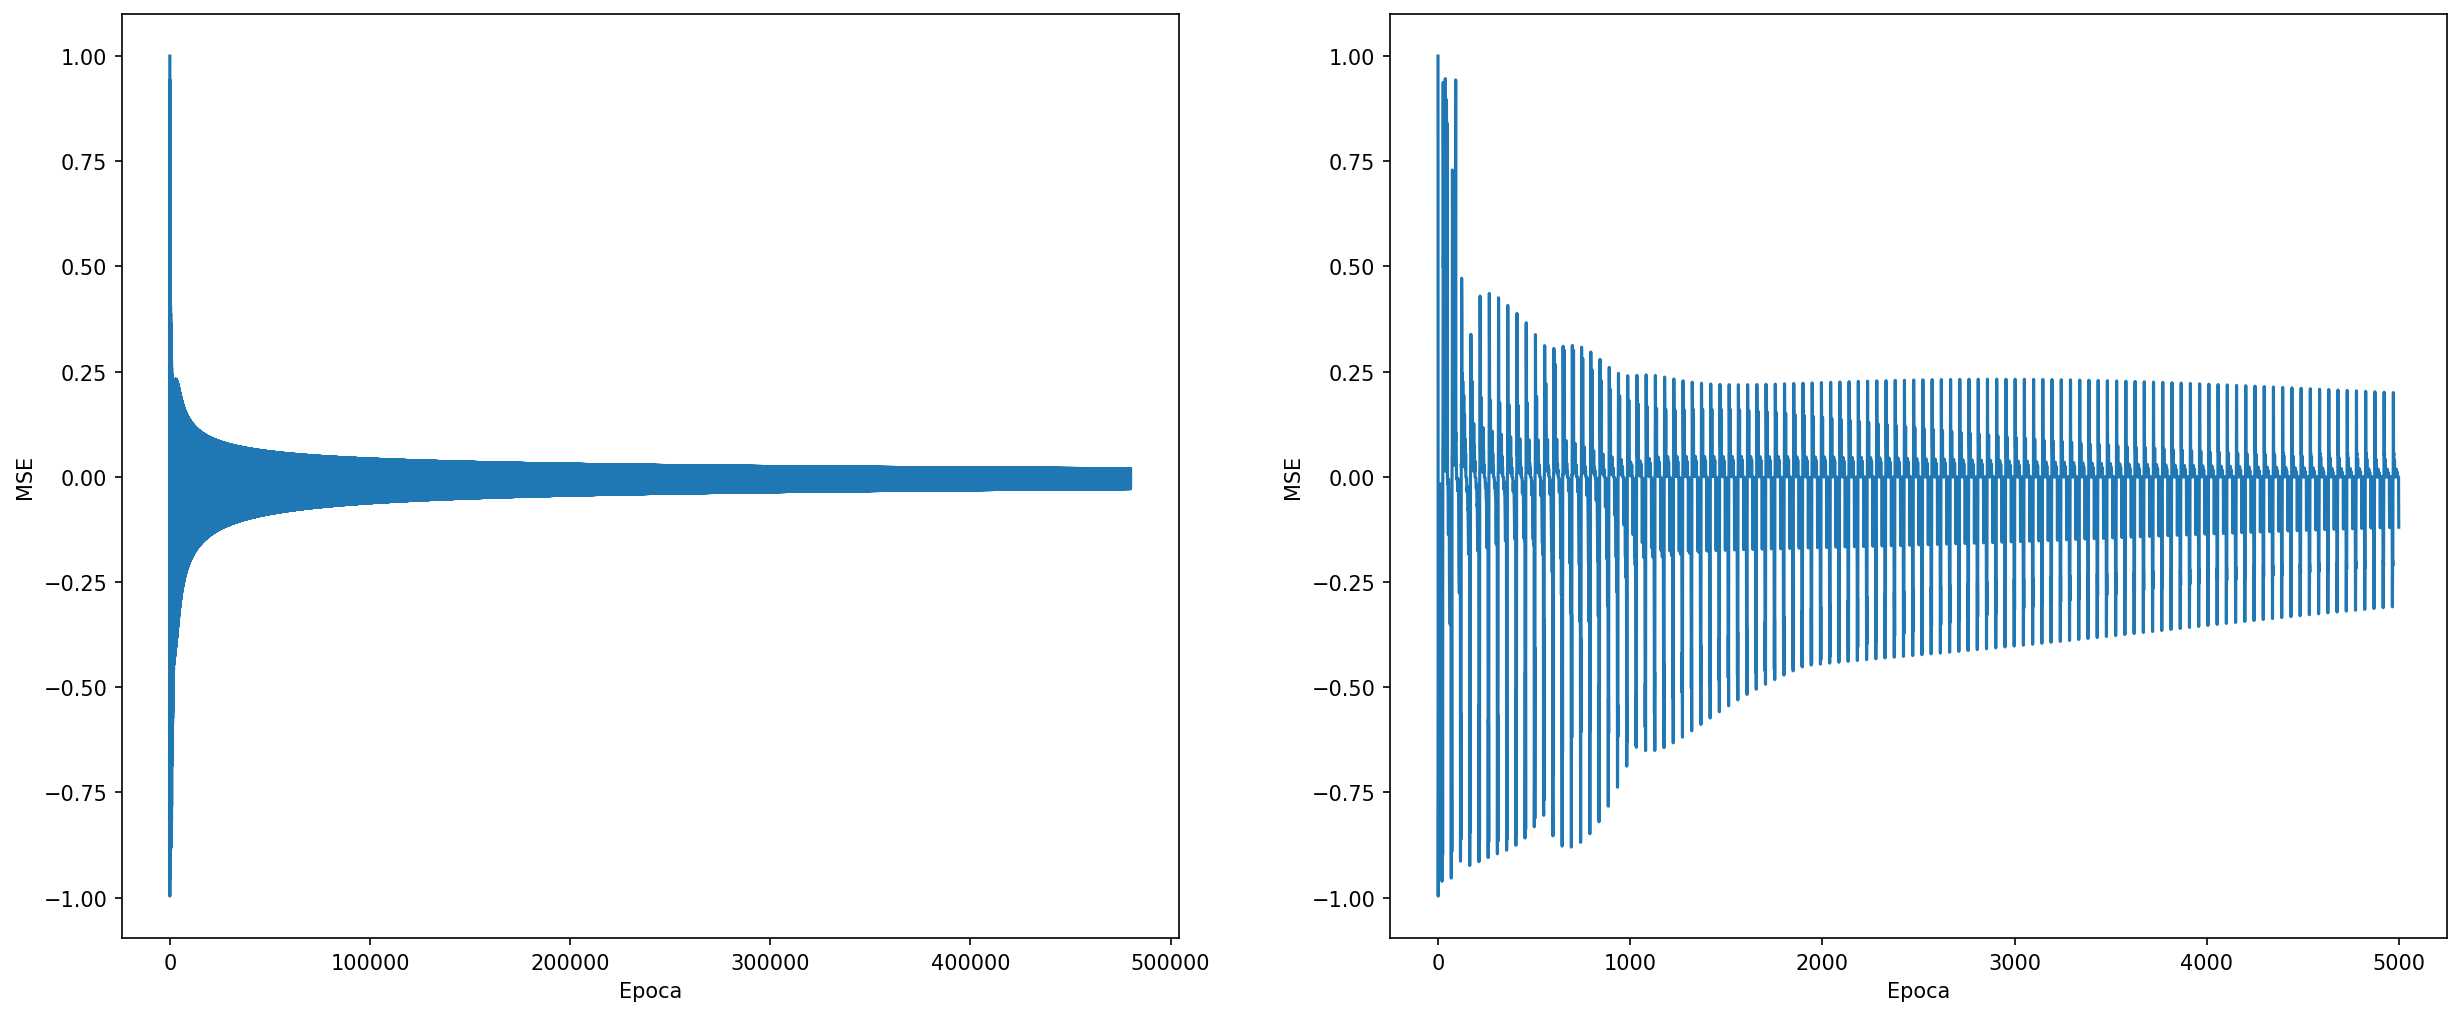

In [ ]:
x1 = range(np.array(lista_tutti_errori).shape[0])
y1 = np.array(lista_tutti_errori)
x2 = x1[:5000]
y2 = y1[:5000]

fig, ax = plt.subplots(1, 2, figsize=(20, 8), dpi=150)

ax[0].plot(x1,y1)
ax[0].set_xlabel("Epoca")
ax[0].set_ylabel("MSE")

ax[1].plot(x2,y2)
ax[1].set_xlabel("Epoca")
ax[1].set_ylabel("MSE")

### test

In [ ]:
test_x_pca = pca.transform(test_x)

In [ ]:
prediction = neural_predict(
    weights_pca,
    test_x_pca
)

In [ ]:
prediction

array([0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 0.])